In [11]:
import glob

import imageio.v3 as iio
import ipympl
import matplotlib.pyplot as plt
import numpy as np
import skimage as ski
from skimage import filters
from skimage import morphology
from skimage import measure
from scipy import ndimage as ndi

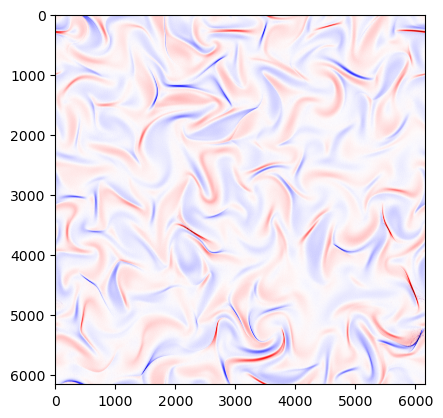

In [2]:
# load the image
shapes01 = iio.imread(uri="CS.png")

fig, ax = plt.subplots()
ax.imshow(shapes01)

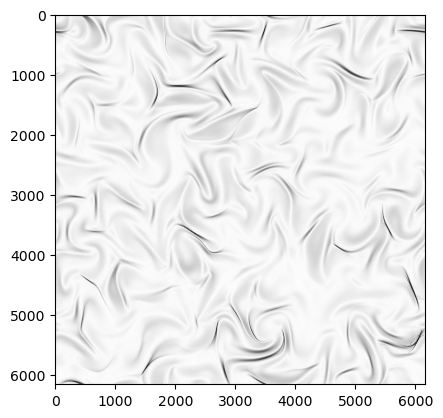

In [3]:
if shapes01.shape[-1] == 4:
    shapes01 = shapes01[..., :3]

# convert the image to grayscale
gray_shapes = ski.color.rgb2gray(shapes01)

# blur the image to denoise
blurred_shapes = ski.filters.gaussian(gray_shapes, sigma=1.0)

fig, ax = plt.subplots()
ax.imshow(blurred_shapes, cmap="gray")

(0.0, 1.0)

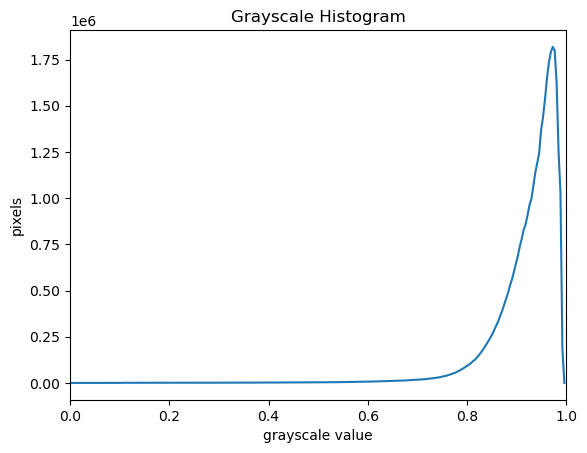

In [4]:
# create a histogram of the blurred grayscale image
histogram, bin_edges = np.histogram(blurred_shapes, bins=256, range=(0.0, 1.0))

fig, ax = plt.subplots()
ax.plot(bin_edges[0:-1], histogram)
ax.set_title("Grayscale Histogram")
ax.set_xlabel("grayscale value")
ax.set_ylabel("pixels")
ax.set_xlim(0, 1.0)

Found automatic threshold t = 0.8.


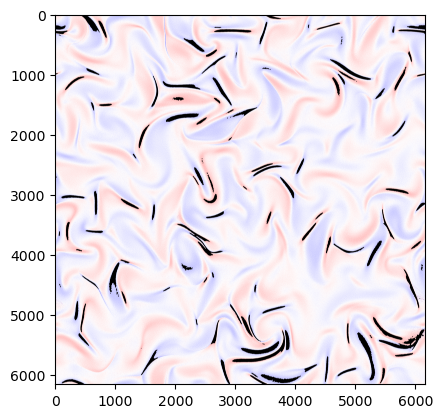

In [5]:
# create a mask based on the threshold
# perform automatic thresholding
t = ski.filters.threshold_otsu(blurred_shapes)
t = 0.8
print("Found automatic threshold t = {}.".format(t))
binary_mask = blurred_shapes > t

# blur the image to denoise
smoothed_binary_mask = ski.filters.gaussian(binary_mask, sigma=5.0)
smoothed_binary_mask = smoothed_binary_mask > 0.5

# Remove small objects and smooth edges
smoothed_binary_mask = morphology.binary_opening(smoothed_binary_mask, morphology.disk(5))
smoothed_binary_mask = morphology.binary_closing(smoothed_binary_mask, morphology.disk(5))

# use the binary_mask to select the "interesting" part of the image
selection = shapes01.copy()
selection[~smoothed_binary_mask] = 0

fig, ax = plt.subplots()
ax.imshow(selection)

In [17]:
# # Make sure your mask is boolean
# mask = smoothed_binary_mask.astype(bool)

# # Invert the mask
# inverted_mask = ~mask  # flips True ↔ False

# # Label connected regions in the inverted mask
# labeled_mask = measure.label(inverted_mask, connectivity=2)  # 8-connectivity

# # Count pixels in each structure
# region_props = measure.regionprops(labeled_mask)
# num_points_per_structure = [region.area for region in region_props]

# print("Number of structures:", len(region_props))
# print("Pixels in each structure:", num_points_per_structure)

Number of structures: 87
Pixels in each structure: [np.float64(29247.0), np.float64(7028.0), np.float64(11268.0), np.float64(29904.0), np.float64(20488.0), np.float64(1854.0), np.float64(23063.0), np.float64(1807.0), np.float64(6285.0), np.float64(19319.0), np.float64(7072.0), np.float64(1986.0), np.float64(5946.0), np.float64(33469.0), np.float64(5885.0), np.float64(13771.0), np.float64(780.0), np.float64(3958.0), np.float64(10458.0), np.float64(12654.0), np.float64(22832.0), np.float64(25662.0), np.float64(5836.0), np.float64(8101.0), np.float64(7511.0), np.float64(2900.0), np.float64(5338.0), np.float64(1072.0), np.float64(14429.0), np.float64(33174.0), np.float64(5312.0), np.float64(4853.0), np.float64(13184.0), np.float64(8052.0), np.float64(28418.0), np.float64(12662.0), np.float64(15766.0), np.float64(11921.0), np.float64(14596.0), np.float64(10624.0), np.float64(12966.0), np.float64(11086.0), np.float64(5655.0), np.float64(6727.0), np.float64(8376.0), np.float64(5102.0), np.flo

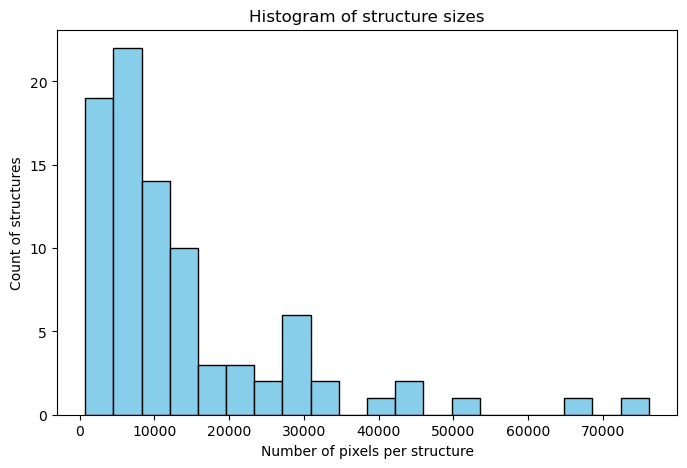

In [18]:
# Plot histogram
plt.figure(figsize=(8, 5))
plt.hist(num_points_per_structure, bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Number of pixels per structure")
plt.ylabel("Count of structures")
plt.title("Histogram of structure sizes")
plt.show()

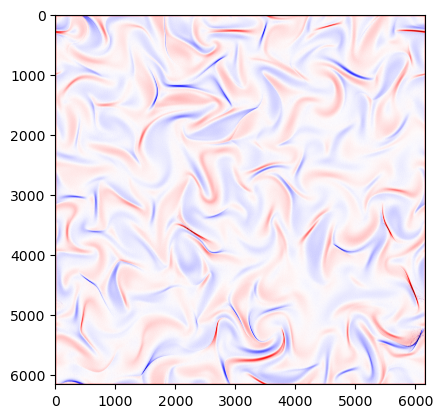

In [20]:
# from skimage import measure
# import matplotlib.patches as patches
# import matplotlib.pyplot as plt

# # Label regions
# labeled_mask = measure.label(smoothed_binary_mask.astype(bool), connectivity=2)
# region_props = measure.regionprops(labeled_mask)

# fig, ax = plt.subplots()
# ax.imshow(shapes01)

# for region in region_props:
#     # Get the bounding box: (min_row, min_col, max_row, max_col)
#     minr, minc, maxr, maxc = region.bbox
#     width = maxc - minc
#     height = maxr - minr
    
#     # Draw rectangle
#     rect = patches.Rectangle((minc, minr), width, height, edgecolor='red', facecolor='none', linewidth=1)
#     ax.add_patch(rect)

# plt.show()

In [10]:
# Make sure your mask is boolean
mask = smoothed_binary_mask.astype(bool)

# Invert the mask
inverted_mask = ~mask  # flips True ↔ False

# Label connected regions in the inverted mask
labeled_mask = measure.label(inverted_mask, connectivity=2)  # 8-connectivity

# Count pixels in each structure
region_props = measure.regionprops(labeled_mask)

print("Number of structures:", len(region_props))

Number of structures: 153
Pixels in each structure: [np.float64(29700.0), np.float64(70.0), np.float64(73.0), np.float64(8904.0), np.float64(12041.0), np.float64(11682.0), np.float64(8750.0), np.float64(874.0), np.float64(13470.0), np.float64(9539.0), np.float64(2838.0), np.float64(1474.0), np.float64(23555.0), np.float64(13705.0), np.float64(7733.0), np.float64(190.0), np.float64(114.0), np.float64(267.0), np.float64(20225.0), np.float64(759.0), np.float64(378.0), np.float64(7496.0), np.float64(4432.0), np.float64(1003.0), np.float64(12781.0), np.float64(125.0), np.float64(34472.0), np.float64(532.0), np.float64(1747.0), np.float64(7302.0), np.float64(213.0), np.float64(14995.0), np.float64(81.0), np.float64(7337.0), np.float64(689.0), np.float64(2808.0), np.float64(5641.0), np.float64(13629.0), np.float64(12329.0), np.float64(12873.0), np.float64(24375.0), np.float64(27873.0), np.float64(112.0), np.float64(7223.0), np.float64(100.0), np.float64(6875.0), np.float64(3790.0), np.float64

In [12]:
thicknesses = []
for i in range(1, labeled_mask.max() + 1):
    region = labeled_mask == i
    if np.sum(region) < 10:  # ignore tiny ones
        continue
    dist = ndi.distance_transform_edt(region)
    thickness = 2 * dist.max()  # full thickness
    thicknesses.append(thickness)

print(f"Found {len(thicknesses)} sheets with mean thickness = {np.mean(thicknesses):.2f} px")

Found 153 sheets with mean thickness = 34.36 px


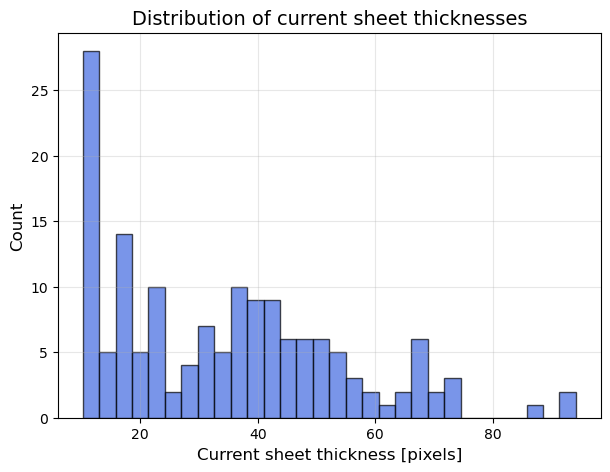

In [13]:
import matplotlib.pyplot as plt
import numpy as np

thicknesses = np.array(thicknesses)
thicknesses = thicknesses[thicknesses > 0]  # remove any zero entries

plt.figure(figsize=(7,5))
plt.hist(thicknesses, bins=30, color='royalblue', edgecolor='k', alpha=0.7)
plt.xlabel('Current sheet thickness [pixels]', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of current sheet thicknesses', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
print(shapes01.shape)

(6160, 6160, 3)
